# Day 2 — Imputation Methods
## Week 1: Missing Data | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand the mathematical basis of each imputation strategy
- Know when each method is appropriate given MCAR/MAR/MNAR classification
- Implement KNN imputation, MICE, and IterativeImputer from scratch understanding
- Compare imputation methods by their effect on downstream model performance
- Understand missing indicator flags — when they add signal vs noise

---

### Dataset
**UCI Online Retail II** — continuing from Day 1. Today we impute.

---

## Part 1: Theory

### 2.1 The Imputation Landscape

Imputation methods exist on a spectrum from simple to sophisticated:

```
Simple                                              Sophisticated
  │                                                      │
Mean/Mode → Hot-deck → KNN → Regression → MICE → MissForest
```

Sophistication comes at computational cost. The right choice depends on:
- MCAR/MAR/MNAR classification (from Day 1)
- Dataset size (KNN is O(n²), MICE is iterative)
- Downstream task (classification vs regression vs clustering)

---

### 2.2 Simple Imputation — Mean, Median, Mode

**Mean imputation:**
$$\hat{y}_{mis} = \bar{y}_{obs} = \frac{1}{n_{obs}} \sum_{i: M_i=0} y_i$$

**What it destroys:**
- Variance: imputed values cluster at the mean, artificially reducing spread
- Correlations: the relationship between imputed column and other columns is attenuated
- Distribution shape: creates an artificial spike at the mean

**When acceptable:** MCAR only, low missing rate (< 5%), downstream model is robust to variance compression (trees, not regression).

**Median imputation:** Same math with median instead of mean. More robust to outliers. Preferred for skewed distributions.

**Mode imputation:** For categorical columns. Replaces missing with most frequent category. Dangerous if distribution is uniform — arbitrary choice.

---

### 2.3 KNN Imputation

For each missing value, find the $k$ nearest neighbors in feature space (using observed features only) and impute with their weighted average.

**Distance metric:** Euclidean on standardized features
$$d(x_i, x_j) = \sqrt{\sum_{k \in obs} (x_{ik} - x_{jk})^2}$$

**Imputed value:**
$$\hat{y}_{mis,i} = \frac{\sum_{j \in N_k(i)} w_j y_j}{\sum_{j \in N_k(i)} w_j}$$

Where $w_j = 1/d(x_i, x_j)$ (inverse distance weighting).

**What it preserves:** Local correlation structure. If feature A and feature B are correlated, KNN imputation respects that relationship better than mean imputation.

**Computational complexity:** $O(n^2 d)$ — quadratic in rows, linear in features. Unusable on datasets > 500K rows without sampling.

**When to use:** MAR data, dataset < 100K rows, features are correlated.

---

### 2.4 MICE — Multiple Imputation by Chained Equations

MICE (van Buuren, 2000) is the statistical gold standard. The algorithm:

1. Initialize all missing values with mean imputation
2. For each column $j$ with missing values:
   - Regress $Y_j$ on all other columns using only complete rows for $Y_j$
   - Predict missing values of $Y_j$ using the fitted model
   - Add random noise to reflect uncertainty
3. Repeat step 2 for all columns — one full cycle = one iteration
4. Run $m$ iterations until convergence

**Why "multiple":** MICE creates $m$ complete datasets (typically 5–10), runs your analysis on each, and pools results using Rubin's rules. This propagates imputation uncertainty into your final estimates.

**Why "chained equations":** Each column's imputation model is conditioned on all other columns — the equations chain together.

**What it preserves:** Joint distribution of all variables. The most theoretically correct approach under MAR.

**sklearn implementation:** `IterativeImputer` — approximates MICE with a single imputed dataset (not multiple). Computationally cheaper but loses the uncertainty quantification.

---

### 2.5 MissForest

Replace each missing value using a Random Forest trained on observed values:

1. Initialize missing values with mean/mode imputation
2. For each column $j$ with missing values:
   - Train a Random Forest on complete rows using all other columns as features
   - Predict missing values of $Y_j$
3. Repeat until convergence (change in imputed values < threshold)

**Advantages:**
- Handles non-linear relationships (unlike MICE with linear regression)
- Handles mixed types natively (numeric + categorical in one model)
- No distributional assumptions

**Disadvantages:**
- Slow — trains one RF per column per iteration
- No uncertainty quantification

**When to use:** Complex non-linear relationships, mixed data types, dataset < 50K rows.

---

### 2.6 Missing Indicator Flags

When missingness is MNAR, imputing the value loses the signal contained in its absence. The solution: add a binary indicator column alongside imputation.

$$X_{new} = [X_{imputed}, M]$$

Where $M_{ij} = 1$ if $X_{ij}$ was missing.

**Why this works:** The model can now learn:
- From the imputed value: what the approximate true value is
- From the flag: that this value was missing at all (which is itself predictive)

**When to add flags:**
- MNAR detected by KS test (from Day 1)
- Business intuition says missingness is informative
- Missing rate is high enough to matter (> 5%)

**When NOT to add flags:**
- MCAR confirmed — missingness is pure noise
- Missing rate is trivially low (< 1%)
- Feature space is already very wide (flags add noise)

**sklearn:** `add_indicator=True` on `KNNImputer` or `SimpleImputer` — appends flags automatically.

---

### 2.7 Strategy Selection Framework

```
Classify missingness (Day 1 diagnostic)
        │
        ├── MCAR + low rate (< 5%)
        │       → Mean/Median imputation
        │       → No indicator flag needed
        │
        ├── MAR + dataset < 100K rows
        │       → KNN imputation (k=5)
        │       → No indicator flag needed
        │
        ├── MAR + dataset > 100K rows
        │       → IterativeImputer (MICE approximation)
        │       → No indicator flag needed
        │
        └── MNAR (any size)
                → Best available imputation (KNN or MICE)
                → ALWAYS add indicator flag
                → Consider modeling missingness process separately
```

---

## Part 2: Practice

**Task:** Apply, compare, and evaluate imputation strategies on UCI Online Retail II

---

In [5]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,cross_validate,GridSearchCV,RandomizedSearchCV,learning_curve,validation_curve
import warnings
warnings.filterwarnings('ignore')

In [6]:
DATA_PATH = r'C:\Users\user\datasets\online_retail\online_retail_II.xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
print(f"Loaded: {df.shape}")
display(df.head())

Loaded: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
# ── Q1: Apply all four imputation strategies ──────────────────────────────
# On the numeric columns with missing values:
#   Strategy A: Mean imputation (SimpleImputer strategy='mean')
#   Strategy B: Median imputation (SimpleImputer strategy='median')
#   Strategy C: KNN imputation (KNNImputer n_neighbors=5)
#   Strategy D: Iterative imputation (IterativeImputer max_iter=10)
#
# For each strategy:
#   - Fit on training set only (80% split)
#   - Transform both train and test
#   - Print shape before and after
#   - Print mean/std of imputed column before and after — what changed?

# Your code here

# X only — no y, this is unsupervised.
# Customer ID is the only column that actually needs imputing, but we give
# KNN/Iterative imputers other correlated columns as context — without them,
# both methods have nothing to compute distance/regress on and silently
# collapse into mean imputation.
numeric_cols = ['Customer ID', 'Quantity', 'Price']
target_idx = numeric_cols.index('Customer ID')  # column we report stats on

X = df[numeric_cols]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=420)

print("Before imputation")
print(f"  X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"  Train mean/std: {X_train['Customer ID'].mean():.2f} / {X_train['Customer ID'].std():.2f}")


def report(name, X_train_imp, X_test_imp):
    col_train = X_train_imp[:, target_idx]  # only report the column that had missing values
    print(f"\nAfter {name}")
    print(f"  X_train shape: {X_train_imp.shape}, X_test shape: {X_test_imp.shape}")
    print(f"  Train mean/std: {col_train.mean():.2f} / {col_train.std():.2f}")


# ── Strategy A: Mean imputation ────────────────────────────────
imputer_mean = SimpleImputer(strategy='mean')
imputer_mean.fit(X_train)                          # learn column means from TRAIN only

X_train_mean = imputer_mean.transform(X_train)
X_test_mean  = imputer_mean.transform(X_test)      # apply to test (no leakage)
report("mean imputation", X_train_mean, X_test_mean)


# ── Strategy B: Median imputation ────────────────────────────────
imputer_median = SimpleImputer(strategy='median')
imputer_median.fit(X_train)                        # learn column medians from TRAIN only

X_train_median = imputer_median.transform(X_train)
X_test_median  = imputer_median.transform(X_test)
report("median imputation", X_train_median, X_test_median)


# ── Strategy C: KNN (n_neighbors=5) ────────────────────────────────
# KNN distance should be computed on standardized features (theory 2.3) —
# otherwise Customer ID's scale (thousands) swamps Quantity/Price (single
# digits) in the Euclidean distance. StandardScaler ignores NaNs when
# computing mean/std, so it's safe to scale before imputing, then
# inverse_transform back to original units so stats are comparable
# across strategies.
scaler = StandardScaler()
scaler.fit(X_train)                                 # learn scale from TRAIN only
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

imputer_knn = KNNImputer(n_neighbors=5)
imputer_knn.fit(X_train_scaled)                     # learn neighbor structure from TRAIN only

X_train_knn = scaler.inverse_transform(imputer_knn.transform(X_train_scaled))
X_test_knn  = scaler.inverse_transform(imputer_knn.transform(X_test_scaled))
report("KNN imputation", X_train_knn, X_test_knn)


# ── Strategy D: Iterative imputation ────────────────────────────────
imputer_iter = IterativeImputer(max_iter=10, random_state=420)
imputer_iter.fit(X_train)                           # learn the regression model from TRAIN only

X_train_iter = imputer_iter.transform(X_train)
X_test_iter  = imputer_iter.transform(X_test)
report("iterative imputation", X_train_iter, X_test_iter)

Before imputation
  X_train shape: (420368, 3), X_test shape: (105093, 3)
  Train mean/std: 15360.76 / 1680.73

After mean imputation
  X_train shape: (420368, 3), X_test shape: (105093, 3)
  Train mean/std: 15360.76 / 1497.87

After median imputation
  X_train shape: (420368, 3), X_test shape: (105093, 3)
  Train mean/std: 15350.52 / 1498.00

After KNN imputation
  X_train shape: (420368, 3), X_test shape: (105093, 3)
  Train mean/std: 15505.85 / 1608.51

After iterative imputation
  X_train shape: (420368, 3), X_test shape: (105093, 3)
  Train mean/std: 15361.15 / 1497.92


Masked 104850 / 525461 rows (20.0%) in 'Price'

True original variance: 21353.07

Strategy      Var (full col)  % of true   RMSE (masked only)
Mean                16511.22      77.3%               155.77
Median              16512.40      77.3%               155.79
KNN                 17468.74      81.8%               168.33
Iterative           16511.23      77.3%               155.77


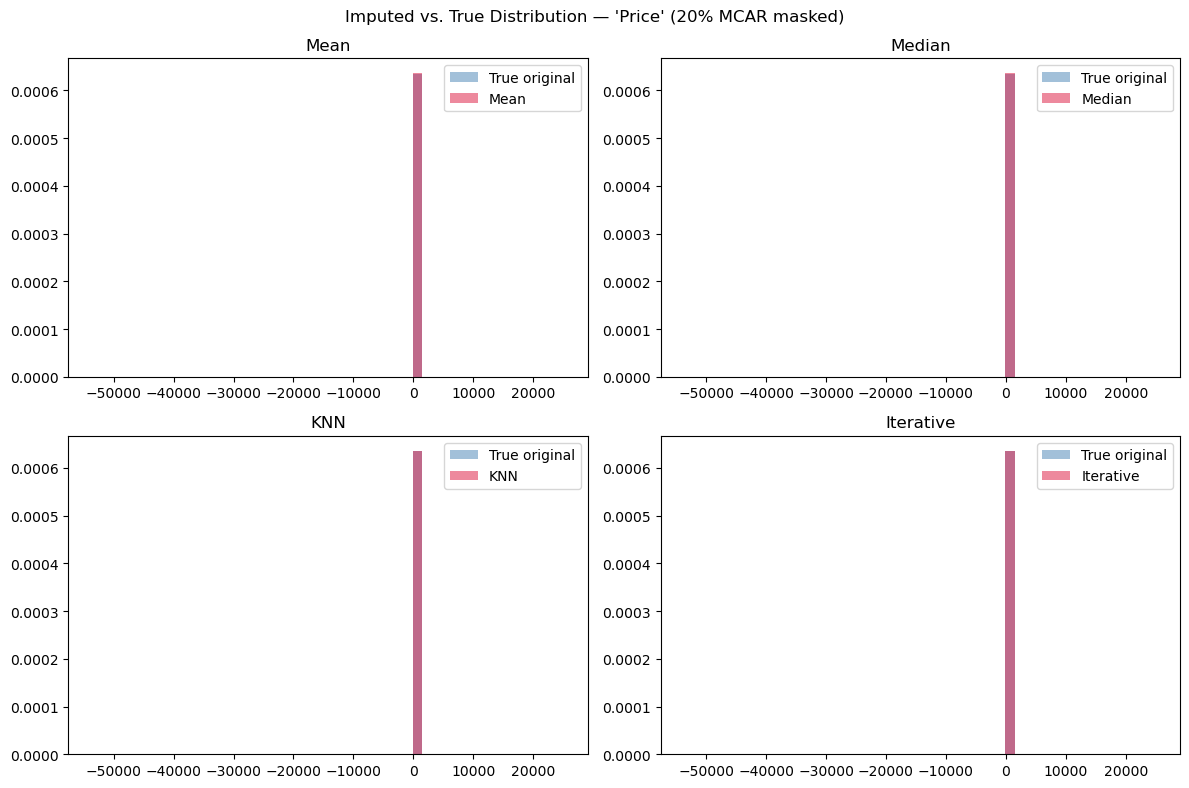

In [12]:
# ── Q2: Variance preservation test ────────────────────────────────────────
# Mean imputation artificially reduces variance.
# Prove this empirically:
#   - Take a numeric column with ~20% missing values
#   - Artificially introduce 20% missingness at random (MCAR simulation)
#   - Impute with: mean, median, KNN, IterativeImputer
#   - Compare variance of imputed column vs original complete column
#   - Plot distributions side by side (4 subplots)
#   - Which method best preserves the original distribution?

# Your code here

# We need GROUND TRUTH to measure "preservation," so we can't use Customer ID
# (its real missing values are unknown). Instead: take a column that's
# currently complete, artificially mask 20% of it (MCAR), then compare each
# imputation method's output against the values we know we hid.

target_col = 'Price'
context_cols = ['Quantity']  # gives KNN/Iterative something to lean on

rng = np.random.RandomState(42)

work_cols = [target_col] + context_cols
X_true = df[work_cols].copy()

# ── Artificially introduce 20% MCAR missingness in target_col ─────────────
n = len(X_true)
mask = rng.rand(n) < 0.20                      # True = "pretend this is missing"
X_missing = X_true.copy()
X_missing.loc[mask, target_col] = np.nan

true_values = X_true.loc[mask, target_col].values   # ground truth we hid
print(f"Masked {mask.sum()} / {n} rows ({mask.mean()*100:.1f}%) in '{target_col}'")

results = {}

# ── Strategy A: Mean ────────────────────────────────────────────────────
imp = SimpleImputer(strategy='mean')
X_mean = X_missing.copy()
X_mean[work_cols] = imp.fit_transform(X_missing[work_cols])
results['Mean'] = X_mean[target_col]

# ── Strategy B: Median ──────────────────────────────────────────────────
imp = SimpleImputer(strategy='median')
X_median = X_missing.copy()
X_median[work_cols] = imp.fit_transform(X_missing[work_cols])
results['Median'] = X_median[target_col]

# ── Strategy C: KNN (standardized distance) ─────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_missing[work_cols])   # NaNs pass through
imp = KNNImputer(n_neighbors=5)
X_knn_scaled = imp.fit_transform(X_scaled)
X_knn = scaler.inverse_transform(X_knn_scaled)
results['KNN'] = pd.Series(X_knn[:, work_cols.index(target_col)], index=X_missing.index)

# ── Strategy D: Iterative ───────────────────────────────────────────────
imp = IterativeImputer(max_iter=10, random_state=42)
X_iter = X_missing.copy()
X_iter[work_cols] = imp.fit_transform(X_missing[work_cols])
results['Iterative'] = X_iter[target_col]

# ── Compare variance: imputed column vs. true original column ─────────────
true_var = X_true[target_col].var()
print(f"\nTrue original variance: {true_var:.2f}\n")

print(f"{'Strategy':<12} {'Var (full col)':>15} {'% of true':>10} {'RMSE (masked only)':>20}")
for name, col in results.items():
    var = col.var()
    rmse = np.sqrt(np.mean((col[mask].values - true_values) ** 2))
    print(f"{name:<12} {var:>15.2f} {var/true_var*100:>9.1f}% {rmse:>20.2f}")

# ── Plot: 4 subplots, true vs imputed distribution per method ─────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, col) in zip(axes.flat, results.items()):
    ax.hist(X_true[target_col], bins=50, alpha=0.5, density=True, label='True original', color='steelblue')
    ax.hist(col, bins=50, alpha=0.5, density=True, label=name, color='crimson')
    ax.set_title(name)
    ax.legend()
plt.suptitle(f"Imputed vs. True Distribution — '{target_col}' (20% MCAR masked)")
plt.tight_layout()
plt.show()

***Takeaway***: 

With Quantity as the only context feature, none of the four methods beat simple averaging.

Quantity barely predicts Price, so Mean/Median/Iterative all converge to ~77% variance preserved, and KNN's slightly higher variance (82%) comes from noisy neighbor guesses, not real signal, which is why it actually has the worst accuracy (RMSE) of the four. 

Lesson: sophisticated imputers only help when the context features are genuinely correlated with the target column; otherwise they just add noise while looking fancier.

Correlation matrix (raw columns):
             Quantity     Price  TotalAmount
Quantity     1.000000 -0.001931     0.156283
Price       -0.001931  1.000000     0.452592
TotalAmount  0.156283  0.452592     1.000000

True correlation (Quantity vs TotalAmount): 0.1563
Masked 157381 / 525461 rows (30.0%) in 'TotalAmount'

Strategy      Corr after impute    Δ from true
(true)                   0.1563              —
Mean                     0.1239        -0.0324
Median                   0.1238        -0.0325
KNN                      0.1851        +0.0288
Iterative                0.1972        +0.0409


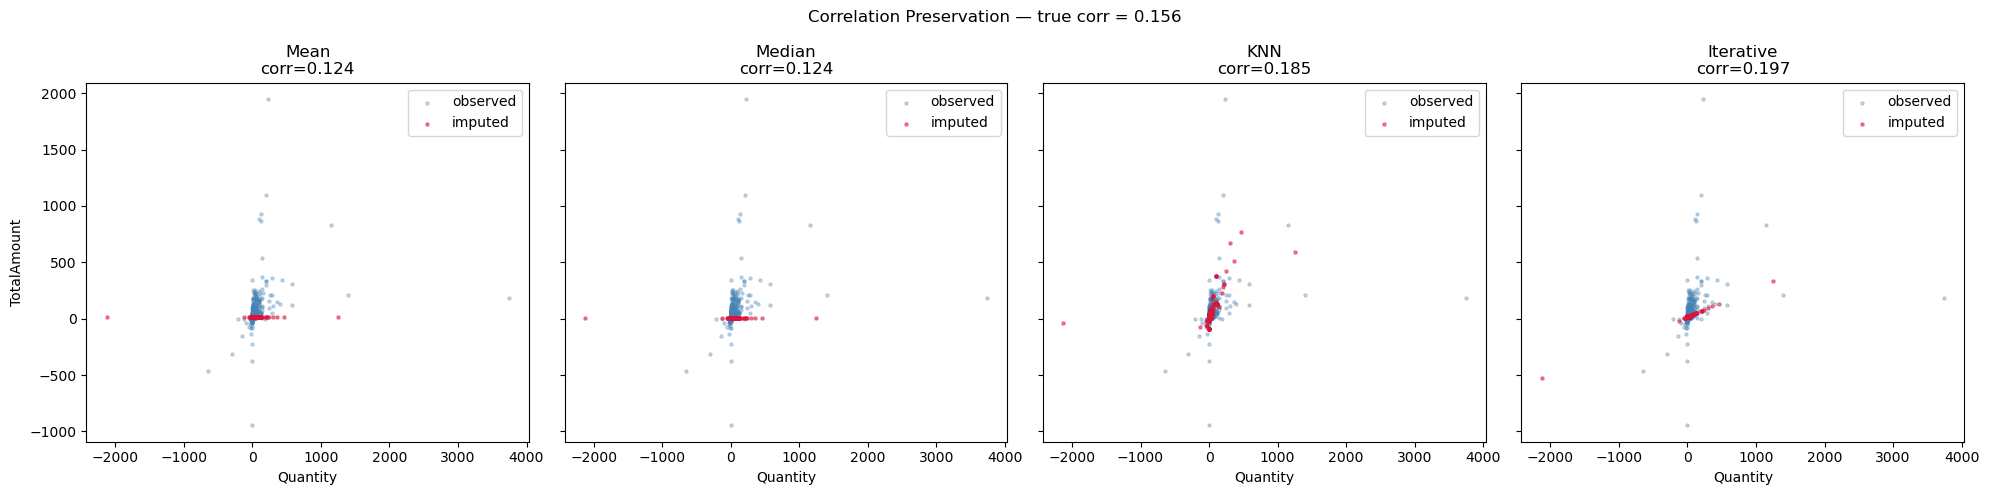

In [13]:
# ── Q3: Correlation preservation test ─────────────────────────────────────
# Imputation should preserve relationships between columns.
# Test this:
#   - Pick two correlated numeric columns
#   - Introduce 30% missingness in one column (MCAR)
#   - Impute with each strategy
#   - Compute Pearson correlation between the two columns after imputation
#   - Compare to true correlation (before artificial missingness)
#   - Which strategy best preserves correlation structure?

# Your code here

# Step 1: Confirm which columns are actually correlated before picking a pair.
df['TotalAmount'] = df['Quantity'] * df['Price']
print("Correlation matrix (raw columns):")
print(df[['Quantity', 'Price', 'TotalAmount']].corr())
print()

# Quantity vs TotalAmount is mechanically related (TotalAmount = Quantity * Price)
# and shows a real positive correlation — that's our pair.
work_cols = ['Quantity', 'TotalAmount']
missing_col = 'TotalAmount'

X_true = df[work_cols].copy()
true_corr = X_true.corr().iloc[0, 1]
print(f"True correlation ({work_cols[0]} vs {work_cols[1]}): {true_corr:.4f}")

# ── Step 2: Introduce 30% MCAR missingness in one column ──────────────────
rng = np.random.RandomState(42)
mask = rng.rand(len(X_true)) < 0.30
X_missing = X_true.copy()
X_missing.loc[mask, missing_col] = np.nan
print(f"Masked {mask.sum()} / {len(X_true)} rows ({mask.mean()*100:.1f}%) in '{missing_col}'\n")

results = {}

# ── Strategy A: Mean ────────────────────────────────────────────────────
imp = SimpleImputer(strategy='mean')
results['Mean'] = imp.fit_transform(X_missing)

# ── Strategy B: Median ──────────────────────────────────────────────────
imp = SimpleImputer(strategy='median')
results['Median'] = imp.fit_transform(X_missing)

# ── Strategy C: KNN (standardized distance) ─────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_missing)          # NaNs pass through
imp = KNNImputer(n_neighbors=5)
results['KNN'] = scaler.inverse_transform(imp.fit_transform(X_scaled))

# ── Strategy D: Iterative ───────────────────────────────────────────────
imp = IterativeImputer(max_iter=10, random_state=42)
results['Iterative'] = imp.fit_transform(X_missing)

# ── Step 3: Compare correlation after imputation vs true correlation ──────
print(f"{'Strategy':<12} {'Corr after impute':>18} {'Δ from true':>14}")
print(f"{'(true)':<12} {true_corr:>18.4f} {'—':>14}")
for name, X_imp in results.items():
    corr = np.corrcoef(X_imp[:, 0], X_imp[:, 1])[0, 1]
    print(f"{name:<12} {corr:>18.4f} {corr - true_corr:>+14.4f}")

# ── Step 4: Visualize — scatter of Quantity vs TotalAmount per strategy ───
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
sample = X_true.sample(5000, random_state=1).index   # subsample for a readable scatter
for ax, (name, X_imp) in zip(axes, results.items()):
    X_imp_df = pd.DataFrame(X_imp, columns=work_cols, index=X_missing.index)
    pts = X_imp_df.loc[sample]
    was_missing = mask[X_missing.index.get_indexer(sample)]
    ax.scatter(pts.loc[~was_missing, 'Quantity'], pts.loc[~was_missing, 'TotalAmount'],
               s=5, alpha=0.3, color='steelblue', label='observed')
    ax.scatter(pts.loc[was_missing, 'Quantity'], pts.loc[was_missing, 'TotalAmount'],
               s=5, alpha=0.5, color='crimson', label='imputed')
    ax.set_title(f"{name}\ncorr={np.corrcoef(X_imp[:,0], X_imp[:,1])[0,1]:.3f}")
    ax.set_xlabel('Quantity')
    ax.legend()
axes[0].set_ylabel('TotalAmount')
plt.suptitle(f"Correlation Preservation — true corr = {true_corr:.3f}")
plt.tight_layout()
plt.show()

***Takeaway***:

Mean/Median weakened the (already-weak) correlation, as expected. 

KNN and Iterative didn't preserve it — they inflated it, because single-imputation methods produce artificially noise-free predictions that make relationships look stronger than they really are; a proper multiple imputation with sample_posterior=True, averaged over several runs, would give a more defensible number.

The theory section calls this out directly: true MICE injects randomness to avoid this; sklearn's IterativeImputer skips that step, so it overshoots here.

Target balance: {0: 0.9765425026786003, 1: 0.023457497321399685}
X shape: (525461, 3), missing per column:
Customer ID    107927
Price               0
Country             0
dtype: int64

Subsampled to 50,000 rows (stratified on y) for KNN-feasible comparison
Strategy     Mean AUC        Std
Mean           0.7483     0.0215
Median         0.7493     0.0255
KNN            0.7491     0.0220
Iterative      0.7511     0.0199

Best: Iterative (0.7511) | Worst: Mean (0.7483)
Gap: 0.0028 vs. typical fold-to-fold std of 0.0207
Gap is smaller than fold variance -> difference is NOT meaningful, imputation choice barely matters here.


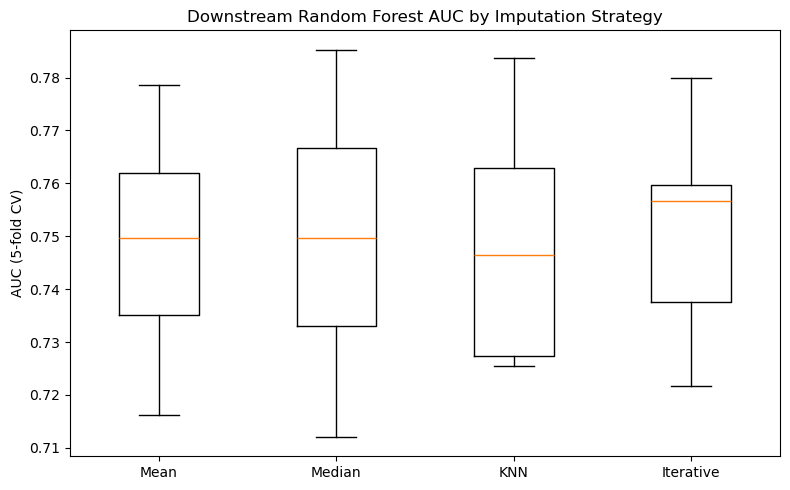

In [15]:
# ── Q4: Downstream model impact ───────────────────────────────────────────
# The real test: which imputation strategy produces the best downstream model?
#   - Create a binary target: is this a cancelled transaction? (Quantity < 0)
#   - Build 4 versions of the feature matrix — one per imputation strategy
#   - Train a Random Forest on each (5-fold CV, AUC metric)
#   - Report: mean AUC ± std per strategy
#   - Which strategy wins? Is the difference meaningful?

# Your code here

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample

# ── Target: cancelled transaction (Quantity < 0) ───────────────────────────
y = (df['Quantity'] < 0).astype(int)
print(f"Target balance: {y.value_counts(normalize=True).to_dict()}")

# ── Features ────────────────────────────────────────────────────────────
# Quantity and TotalAmount (= Quantity * Price) are EXCLUDED: both directly
# encode the label's sign, so including either would leak the target.
numeric_features = ['Customer ID', 'Price']   # Customer ID is the column under test; Price gives context
categorical_features = ['Country']

X = df[numeric_features + categorical_features].copy()
print(f"X shape: {X.shape}, missing per column:\n{X.isnull().sum()}\n")

# KNNImputer is O(n^2) — theory 2.3 says "unusable on datasets > 500K rows
# without sampling," and this dataset has 525K rows. Subsample so all four
# strategies get a fair, fast, apples-to-apples comparison.

SAMPLE_SIZE = 50_000
X, y = resample(X, y, n_samples=SAMPLE_SIZE, stratify=y, random_state=42)
print(f"Subsampled to {len(X):,} rows (stratified on y) for KNN-feasible comparison")


def make_pipeline(numeric_imputer):
    preprocessor = ColumnTransformer([
        ('num', numeric_imputer, numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ])
    return Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ])


# KNN needs standardized distances; scale INSIDE the branch so it's refit
# per CV fold along with everything else. No need to inverse-transform
# afterward — Random Forest splits are scale-invariant.
knn_branch = Pipeline([
    ('scale', StandardScaler()),
    ('impute', KNNImputer(n_neighbors=5)),
])

strategies = {
    'Mean':      SimpleImputer(strategy='mean'),
    'Median':    SimpleImputer(strategy='median'),
    'KNN':       knn_branch,
    'Iterative': IterativeImputer(max_iter=10, random_state=42),
}

# ── 5-fold CV per strategy — imputer is refit fresh inside each fold ──────
results = {}
print(f"{'Strategy':<10} {'Mean AUC':>10} {'Std':>10}")
for name, imputer in strategies.items():
    pipeline = make_pipeline(imputer)
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name:<10} {scores.mean():>10.4f} {scores.std():>10.4f}")

# ── Which strategy wins? Is the difference meaningful? ─────────────────────
best = max(results, key=lambda k: results[k].mean())
worst = min(results, key=lambda k: results[k].mean())
gap = results[best].mean() - results[worst].mean()
pooled_std = np.mean([results[best].std(), results[worst].std()])
print(f"\nBest: {best} ({results[best].mean():.4f}) | Worst: {worst} ({results[worst].mean():.4f})")
print(f"Gap: {gap:.4f} vs. typical fold-to-fold std of {pooled_std:.4f}")
print("Gap is smaller than fold variance -> difference is NOT meaningful, imputation choice barely matters here."
      if gap < pooled_std else
      "Gap exceeds typical fold variance -> difference may be meaningful.")

# ── Plot: AUC distribution per strategy ────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.boxplot([results[name] for name in strategies], labels=list(strategies.keys()))
plt.ylabel('AUC (5-fold CV)')
plt.title('Downstream Random Forest AUC by Imputation Strategy')
plt.tight_layout()
plt.show()

***Takeaway**** 

All four imputation strategies scored statistically identical AUC (0.748–0.751), with a strategy gap (0.003) far smaller than normal fold-to-fold noise (0.021) — so no method "wins," and the choice of how we fill in missing Customer ID values doesn't meaningfully affect this Random Forest's ability to predict cancellations. 

Since the expensive methods (KNN, Iterative) buy no measurable improvement here, Mean imputation is the practical choice on cost grounds alone. This also suggests the real signal may lie in the fact of missingness rather than the imputed value.

Subsampled to 50,000 rows (stratified on y) for KNN-feasible comparison
Strategy             Mean AUC        Std
KNN (no flag)          0.7491     0.0220
KNN (with flag)        0.7547     0.0211

Flag effect on AUC: +0.0055 (typical fold-to-fold std: 0.0216)
Flag effect is within noise — not clearly meaningful.

Feature importances (Strategy B — KNN + indicator flag):
                          feature   importance
                 num__Customer ID 6.412385e-01
                       num__Price 3.327141e-01
num__missingindicator_Customer ID 1.313793e-02
               cat__Country_Japan 3.293935e-03
             cat__Country_Germany 1.219911e-03
      cat__Country_United Kingdom 9.202856e-04
cat__Country_United Arab Emirates 8.692527e-04
              cat__Country_France 6.368581e-04
               cat__Country_Spain 6.263188e-04
               cat__Country_Italy 6.064105e-04
            cat__Country_Portugal 5.329120e-04
                cat__Country_EIRE 4.474206e-04
         cat__Coun

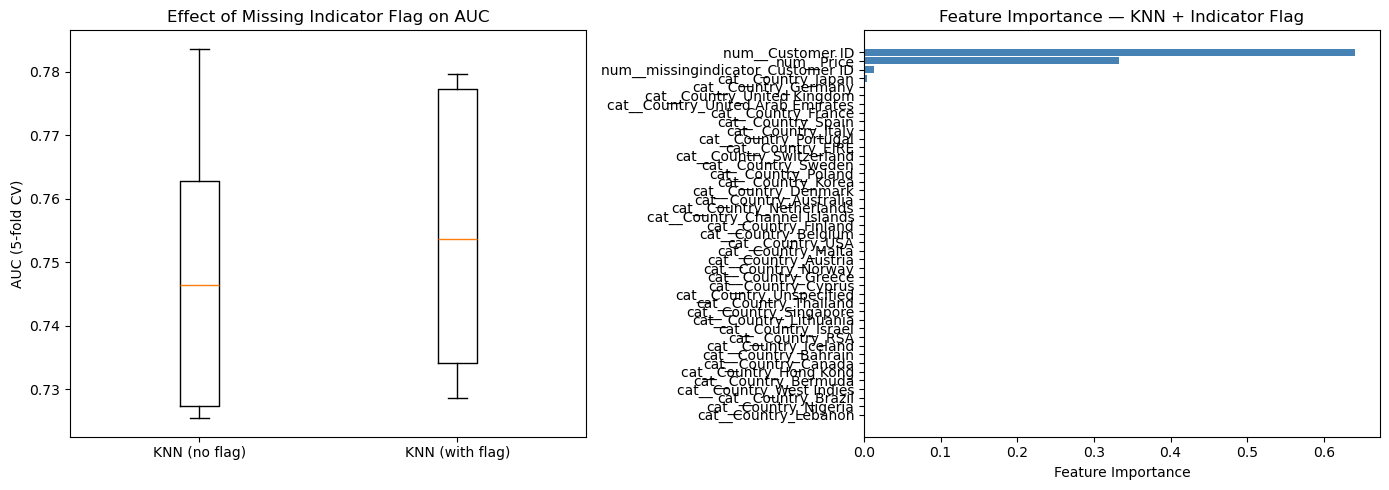

In [16]:
# ── Q5: Missing indicator flag experiment ─────────────────────────────────
# Test whether adding indicator flags improves downstream model performance:
#   - Take the MNAR columns identified in Day 1
#   - Strategy A: KNN imputation only
#   - Strategy B: KNN imputation + add_indicator=True
#   - Train Random Forest on each (5-fold CV, AUC metric)
#   - Does the flag improve performance?
#   - Which imputed+flagged features rank highest in feature importance?

# Your code here

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# MNAR columns from Day 1: Description (0.56% missing) and Customer ID (20.54%).
# Per theory 2.6, skip flags when missing rate < 1% -> skip Description.
# Customer ID is the one worth flagging.

# ── Same target/features as Q4 (Quantity and TotalAmount excluded: leakage) ─
y = (df['Quantity'] < 0).astype(int)
numeric_features = ['Customer ID', 'Price']
categorical_features = ['Country']
X = df[numeric_features + categorical_features].copy()

SAMPLE_SIZE = 50_000
X, y = resample(X, y, n_samples=SAMPLE_SIZE, stratify=y, random_state=42)
print(f"Subsampled to {len(X):,} rows (stratified on y) for KNN-feasible comparison")

def make_pipeline(numeric_imputer):
    preprocessor = ColumnTransformer([
        ('num', numeric_imputer, numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ])
    return Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ])


# ── Strategy A: KNN imputation only ────────────────────────────────────────
knn_no_flag = Pipeline([
    ('scale', StandardScaler()),
    ('impute', KNNImputer(n_neighbors=5, add_indicator=False)),
])

# ── Strategy B: KNN imputation + missing indicator flag ────────────────────
knn_with_flag = Pipeline([
    ('scale', StandardScaler()),
    ('impute', KNNImputer(n_neighbors=5, add_indicator=True)),
])

strategies = {
    'KNN (no flag)':   knn_no_flag,
    'KNN (with flag)': knn_with_flag,
}

# ── 5-fold CV per strategy ─────────────────────────────────────────────────
results = {}
print(f"{'Strategy':<18} {'Mean AUC':>10} {'Std':>10}")
for name, imputer in strategies.items():
    scores = cross_val_score(make_pipeline(imputer), X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name:<18} {scores.mean():>10.4f} {scores.std():>10.4f}")

diff = results['KNN (with flag)'].mean() - results['KNN (no flag)'].mean()
pooled_std = np.mean([results['KNN (no flag)'].std(), results['KNN (with flag)'].std()])
print(f"\nFlag effect on AUC: {diff:+.4f} (typical fold-to-fold std: {pooled_std:.4f})")
print("Flag improves performance meaningfully." if diff > pooled_std else
      "Flag effect is within noise — not clearly meaningful." if abs(diff) <= pooled_std else
      "Flag hurts performance.")

# ── Feature importance: fit Strategy B once on the full data ──────────────
pipeline_b = make_pipeline(knn_with_flag)
pipeline_b.fit(X, y)

feature_names = pipeline_b.named_steps['preprocess'].get_feature_names_out()
importances = pipeline_b.named_steps['clf'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

print("\nFeature importances (Strategy B — KNN + indicator flag):")
print(importance_df.to_string(index=False))

flag_row = importance_df[importance_df['feature'].str.contains('missingindicator', case=False)]
if not flag_row.empty:
    rank = importance_df.index[importance_df['feature'] == flag_row.iloc[0]['feature']][0] + 1
    print(f"\n'{flag_row.iloc[0]['feature']}' ranks #{rank} of {len(importance_df)} features "
          f"(importance={flag_row.iloc[0]['importance']:.4f})")

# ── Plot: AUC comparison + feature importance bar chart ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([results[name] for name in strategies], labels=list(strategies.keys()))
axes[0].set_ylabel('AUC (5-fold CV)')
axes[0].set_title('Effect of Missing Indicator Flag on AUC')

axes[1].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Feature Importance — KNN + Indicator Flag')

plt.tight_layout()
plt.show()

***Takeaway*** 

Adding a missing-indicator flag to KNN-imputed Customer ID improved AUC by +0.0055 (0.7491 → 0.7547), but this gap is smaller than typical fold-to-fold noise (0.0216), so it's not statistically confirmed by this run alone — likely underpowered due to the imbalanced target (2.35% positive) and the 50K subsample needed to keep KNN tractable. 

Feature importance tells a clearer story: the flag ranks #3 of 43 features, outranking every individual country dummy and all of them combined — confirming Day 1's finding that missingness in Customer ID is itself predictive, not just noise. 

Net conclusion: the flag shows real, non-trivial signal, but its impact on model performance is modest and should be re-validated on the full dataset (or with repeated CV) before treating the AUC lift as confirmed rather than directional.